In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from pydantic import BaseModel, Field


from langchain_huggingface import HuggingFaceEndpoint
from langchain_huggingface.chat_models import ChatHuggingFace
from dotenv import load_dotenv
import os

/home/aminul/anaconda3/envs/spector/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

# Initialize HuggingFace LLM
llm = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-20b",
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_KEY")
)

model = ChatHuggingFace(llm=llm)

In [3]:
# Define State Schema
class SentimentSchema(BaseModel):

    sentiment : Literal["positive", "negative"] = Field(description="Sentiment of the text")

In [4]:
# Define State Schema
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')



In [5]:
# Create a structured model with the defined schema
structured_model = model.with_structured_output(
    SentimentSchema,
    method="json_schema"
)


In [6]:
# Create a structured model with the defined schema
structured_model2 = model.with_structured_output(
    DiagnosisSchema,
    method="json_schema"
)

In [7]:
from langchain_core.runnables import RunnableLambda

# Add instruction to prompt
preprocess = RunnableLambda(lambda prompt: prompt + "\n\nReturn your answer in JSON format.")

# Chain with first model
safe_model_1 = preprocess | structured_model

# Chain with second model
safe_model_2 = preprocess | structured_model2



In [8]:
# Use them
response1 = safe_model_1.invoke("Give me the sentiment of this text - 'I love this product!'")

In [9]:
response1

{'sentiment': 'positive'}

In [10]:
# Define Review State
class ReviewState(TypedDict):
    text: str
    sentiment: Literal["positive", "negative"]
    diagonosis: dict
    response : str

In [11]:
# Define workflow functions

def find_sentiment(state: ReviewState):

    prompt = f"What is the sentiment of the following text: {state['text']}"
    
    response = safe_model_1.invoke(prompt)
    
    state['sentiment'] = response['sentiment']
    return state

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagonosis"]:
    if state['sentiment'] == 'positive':
        return "positive_response"
    else:
        return "run_diagonosis"
    

def positive_response(state: ReviewState):

    prompt = f"Generate a positive response for the following review: {state['text']}"
    state['response'] = model.invoke(prompt)
    return{ "response": state['response']}


def run_diagonosis(state: ReviewState):

    prompt = f"""Diagnose the following negative review and provide insights: {state['text']}\n"
    "Retrun issue_type, tone, and urgency. """

    response = safe_model_2.invoke(prompt)
    return { "diagonosis": response}


def negetive_response(state: ReviewState):
    diagnose = state['diagonosis']
    prompt = f"""You are a support assistant.
      The user had a '{diagnose['issue_type']}' issue, sounded '{diagnose['tone']}', and marked urgency as '{diagnose['urgency']}'.
      Write an empathetic, helpful resolution message.
     """

    state['response'] = model.invoke(prompt)
    return{ "response": state['response']}

In [12]:
graph = StateGraph(ReviewState)

# Add nodes and edges
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagonosis', run_diagonosis)
graph.add_node('negetive_response', negetive_response)

# Add edges
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagonosis', 'negetive_response')
graph.add_edge('negetive_response', END)

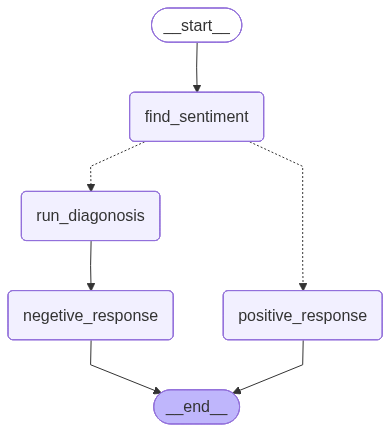

In [13]:
# Compile the workflow
workflow = graph.compile()

workflow

In [14]:
# Define initial state
initial_state: ReviewState = {
    "text": "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.",
    "sentiment": "",
    "diagonosis": {},
    "response": ""
}

In [15]:
# Invoke the workflow
workflow.invoke(initial_state)

{'text': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagonosis': {'issue_type': 'login authentication freeze',
  'tone': 'negative',
  'urgency': 'high'},
 'response': AIMessage(content='Hi there,\n\nI’m really sorry you’re stuck in a login freeze—frustrating, I know. Let’s get you back into your account as quickly and safely as possible.\n\n### Quick Troubleshooting Checklist\n\n| Step | What to do | Why it helps |\n|------|------------|--------------|\n| **1. Clear your browser cache & cookies** | `Settings` → `Privacy` → `Clear browsing data` (make sure “Cookies” and “Cached images & files” are checked). | Old session data can prevent fresh log‑ins. |\n| **2. Try a different browser or incognito mode** | Open Chrome/Edge/Firefox in incognito or private window. | Rules